# X (Formerly Twitter) Bot Detection: Full Analysis

**Author:** Mohamed Bucheeri  
**Capstone Project:** General Assembly Data Science Part 2 (BIBF Bahrain)  
**Date:** April 2026


## Abstract
This notebook covers the training, evaluation, explainability, and external validation of a bot detector trained on 37,438 labelled X (formerly Twitter) profiles. We compare three classifiers (BiGRU-LSTM, CNN-BiLSTM, XGBoost) and the deployed XGBoost model reaches F1 = 0.8076 and ROC-AUC = 0.9329 on the held-out test set. We add per-prediction feature contributions for transparency, test a Sentence-BERT bio embedding fusion experiment as a negative result, run a custom 50-organisation benchmark to validate the news-organisation override, run an external architecture-transfer evaluation on the MGTAB published dataset, and extend the Chrome extension with multi-context thread analysis and coordinated inauthentic behaviour detection.

## Personal Motivation
As an active social media user, I, like many others, struggle daily with knowing what to believe online. Trending topics can be inflated by coordinated automated accounts, viral conversations can turn out to be manufactured, and political opinions in my feed are often shaped by content whose origin I cannot verify. Peer reviewed research has shown that automated accounts amplify low-credibility content (Shao et al., 2018), distort political discourse during major elections (Bessi and Ferrara, 2016), and increase user exposure to negative and inflammatory material (Stella, Ferrara and De Domenico, 2018). The 2024 Imperva Bad Bot Report estimated that almost half of all internet traffic is now automated (Imperva, 2024). Existing bot detection tools either require academic API access or sit behind paywalls, leaving ordinary users with no accessible defence. This project addresses that gap by training a bot classifier on public labelled data and deploying it as a Chrome browser extension that gives a verdict on any Twitter/X profile in seconds.

## Notebook Contents
1. Exploratory Data Analysis: dataset overview, class balance, feature distributions
2. Feature Engineering and Analysis: correlations, importance rankings
3. Model Comparison: performance metrics, ROC curves, confusion matrices
4. Live Demo: predictions on sample profiles
5. Real Model Explainability via XGBoost feature contributions
6. Sentence-BERT Bio Embedding Experiment (negative result)
7. Custom Benchmark on 50 Verified Organisations
8. External Validation on MGTAB
9. Multi-Context Thread Analysis and CIB Detection

In [1]:
import os
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")

import sys
sys.path.insert(0, '..')

import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier

from src.data import load_and_preprocess
from src.config import numeric_features, checkpoints

plt.style.use('dark_background')
plt.rcParams.update({
    'figure.dpi': 100,
    'savefig.dpi': 150,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'legend.fontsize': 10,
    'figure.titleweight': 'bold',
})

human_color = '#34C759'
bot_color = '#FF3B30'
model_colors = {'bigru_lstm': '#1f77b4', 'cnn_bilstm': '#ff7f0e', 'xgboost': '#2ca02c'}

## 1. Exploratory Data Analysis

Before training any models, we need to answer: how big is the dataset, how is it balanced between classes, and which features look different between humans and bots. Each finding here directly shapes a later modelling decision.

### 1.1 Dataset Overview
We will first on the dataset's scale and label distribution. Below loads the preprocessed data and prints a summary table.

In [2]:
# Load preprocessed dataset
users_df, texts, labels, splits, user_ids = load_and_preprocess()
users_df['text_length'] = [len(t) for t in texts]

# Summary table
n_total = len(users_df)
n_humans = int((users_df['label'] == 0).sum())
n_bots = int((users_df['label'] == 1).sum())
summary = pd.DataFrame({
    'Metric': ['Total users', 'Human accounts', 'Bot accounts',
               'Class ratio (human:bot)', 'Numeric features',
               'Train / Val / Test split'],
    'Value': [f'{n_total:,}',
              f'{n_humans:,} ({n_humans/n_total:.1%})',
              f'{n_bots:,} ({n_bots/n_total:.1%})',
              f'{n_humans/n_bots:.2f} : 1',
              f'{len(numeric_features)}',
              f'{len(splits["train"]):,} / {len(splits["val"]):,} / {len(splits["test"]):,}'],
})
print('Table 1: Dataset Summary Statistics')
print('=' * 55)
summary

[*] Loading dataset...
    Rows: 37,438
    Bots: 12,425  |  Humans: 25,013
    Engineered 37 features
    Split: train=26,206 val=5,616 test=5,616
[+] Preprocessed 37,438 users
Table 1: Dataset Summary Statistics


,Metric,Value
0,Total users,"37,438"
1,Human accounts,"25,013 (66.8%)"
2,Bot accounts,"12,425 (33.2%)"
3,Class ratio (human:bot),2.01 : 1
4,Numeric features,37
5,Train / Val / Test split,"26,206 / 5,616 / 5,616"


The dataset contains 37,438 labelled accounts, which is enough volume for stable model training but small compared to academic benchmarks like TwiBot-22 (around 1 million users). The class split is around two humans for every bot. This matters for two reasons. First, a basic model that always predicts human would already be 66.8% accurate, so accuracy alone is misleading and we need to rely more on F1 and ROC-AUC. Second, the imbalance means we should weight the loss function so the model does not learn to ignore the minority bot class. Both decisions are applied later in the training pipeline.

### 1.2 Class Distribution
Visualasitation of the class distribution of the dataset.

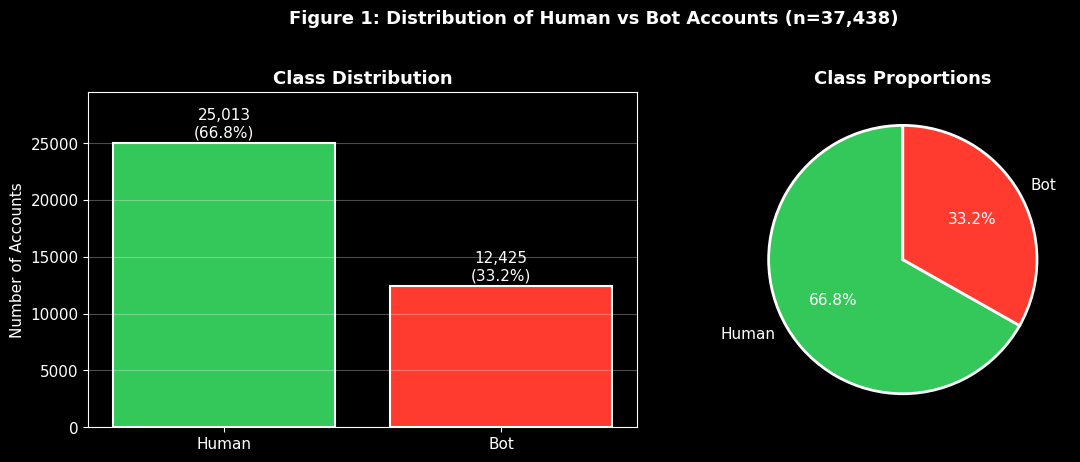

In [3]:
# Figure 1: class distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

counts = users_df['label'].value_counts().sort_index()
bars = ax1.bar(['Human', 'Bot'], counts.values,
               color=[human_color, bot_color], edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 300,
             f'{val:,}\n({val/n_total:.1%})', ha='center', va='bottom', fontsize=11)
ax1.set_ylabel('Number of Accounts')
ax1.set_title('Class Distribution')
ax1.set_ylim(0, max(counts.values) * 1.18)
ax1.grid(axis='y', alpha=0.3)

ax2.pie(counts.values, labels=['Human', 'Bot'],
        colors=[human_color, bot_color],
        autopct='%1.1f%%', startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax2.set_title('Class Proportions')

plt.suptitle('Figure 1: Distribution of Human vs Bot Accounts (n=37,438)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

Humans (25,013 accounts) outnumber bots (12,425 accounts) by around 2 to 1. This is a moderately imbalanced classification problem, not a severely imbalanced one, so we do not need to use techniques like SMOTE or focal loss. We need to give the bot class extra weight during training. The training script does this with a positive class weight of 2.03 for the neural networks and `scale_pos_weight` of 2.03 for XGBoost. Without this adjustment the model would optimise for the majority class and miss real bots.

### 1.3 Feature Distributions
Class balance tells us how many of each there are. Feature distributions tell us whether the features actually distinguish them. We plot the six features that the Random Forest baseline ranked as most discriminative, with humans and bots overlaid in green and red.

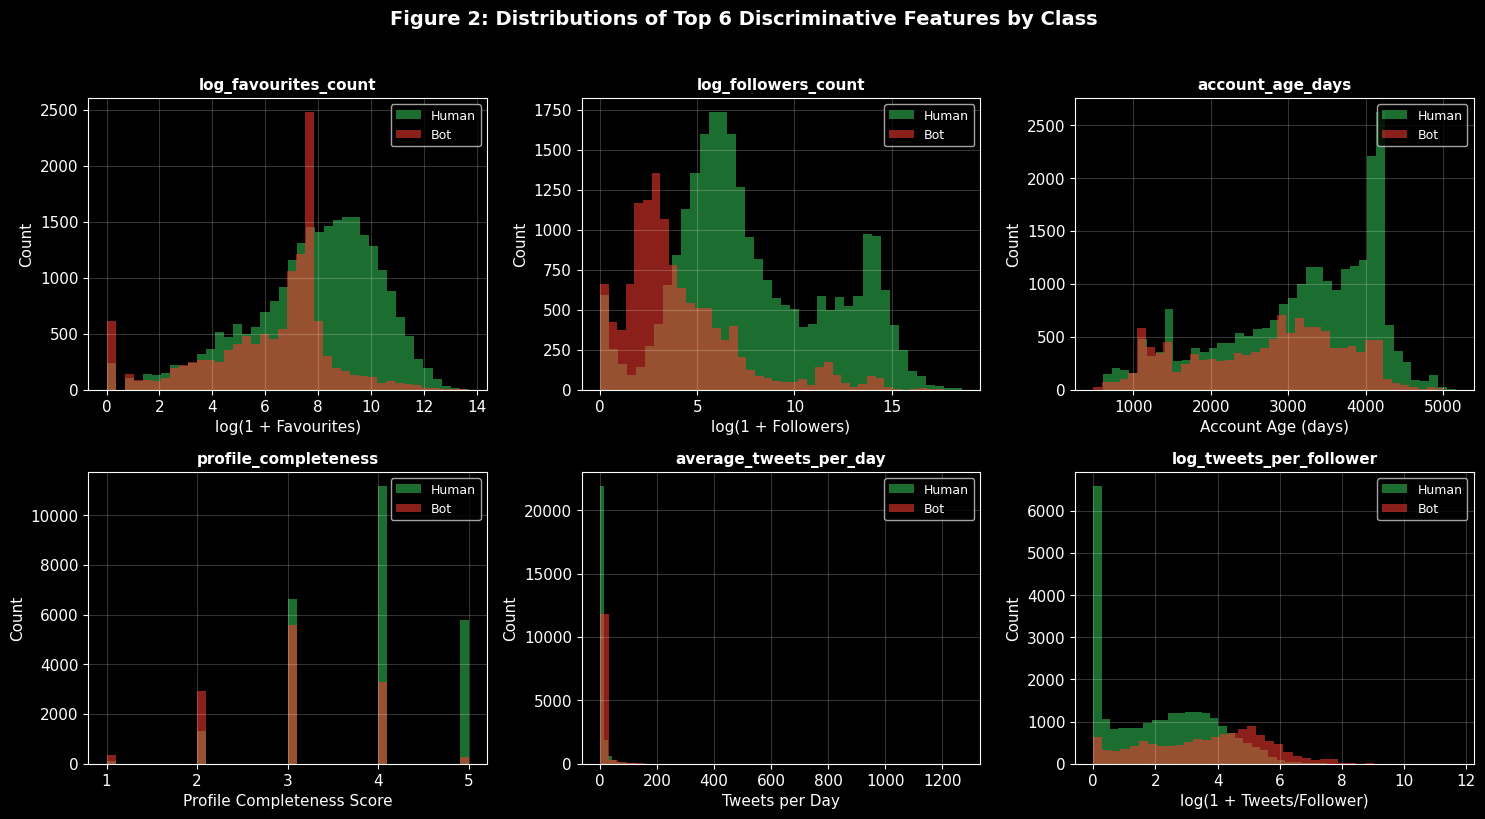

In [4]:
# Figure 2: distribution of top discriminative features
top_features = [
    ('log_favourites_count', 'log(1 + Favourites)'),
    ('log_followers_count', 'log(1 + Followers)'),
    ('account_age_days', 'Account Age (days)'),
    ('profile_completeness', 'Profile Completeness Score'),
    ('average_tweets_per_day', 'Tweets per Day'),
    ('log_tweets_per_follower', 'log(1 + Tweets/Follower)'),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, (feat, label) in zip(axes.ravel(), top_features):
    for cls, color, name in [(0, human_color, 'Human'), (1, bot_color, 'Bot')]:
        data = users_df[users_df['label'] == cls][feat]
        ax.hist(data, bins=40, alpha=0.55,
                color=color, label=name, edgecolor='none')
    ax.set_xlabel(label)
    ax.set_ylabel('Count')
    ax.set_title(feat, fontsize=11)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(alpha=0.2)

plt.suptitle('Figure 2: Distributions of Top 6 Discriminative Features by Class',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Each panel shows the bot and human distributions side by side. `log_favourites_count` (top left) has bots concentrated near zero with a long left peak, while humans spread between 4 and 12. `log_followers_count` shows a similar shape: bots cluster below 5, humans extend past 15. `account_age_days` shows bots overrepresented in accounts under 1,500 days. `profile_completeness` is a 0 to 5 score, and bots cluster at 1 to 2 while humans cluster at 3 to 5. `average_tweets_per_day` has a long right tail occupied almost entirely by bots posting more than 100 tweets per day. `log_tweets_per_follower` shows bots posting at a higher rate relative to their audience size than humans do.

Every panel has overlap between the two classes, so no single feature separates them cleanly. Classification depends on the combined signal across features, not on one strong cut.

### 1.4 Profile Description Length
Final EDA check: how long are bios for the two classes?

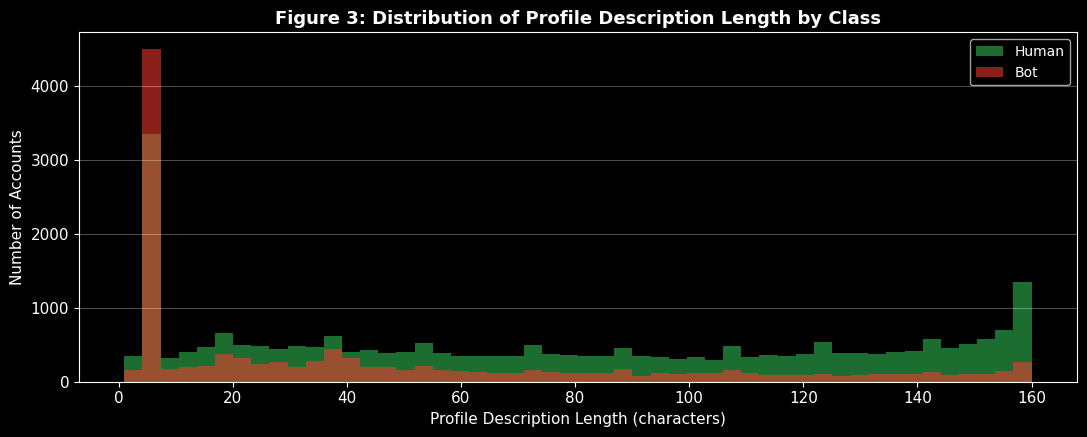

In [5]:
# Figure 3: text length distribution
fig, ax = plt.subplots(figsize=(11, 4.5))
for cls, color, name in [(0, human_color, 'Human'), (1, bot_color, 'Bot')]:
    data = users_df[users_df['label'] == cls]['text_length']
    ax.hist(data, bins=50, alpha=0.55, color=color, label=name, edgecolor='none')
ax.set_xlabel('Profile Description Length (characters)')
ax.set_ylabel('Number of Accounts')
ax.set_title('Figure 3: Distribution of Profile Description Length by Class')
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

The tall red spike near zero characters is the clearest single signal in this entire EDA. Many bot accounts have empty or near empty bios (the dataset preprocessing replaces empty strings with the placeholder `<EMPTY>` which still has very few characters). Human accounts spread more evenly across the full range. There are still humans with short bios and bots with long bios, but the asymmetry at zero is strong enough that bio length on its own becomes a useful weak signal. This is captured in the `description_length` and `has_description` features that feed into all three classifiers.

## 2. Feature Engineering and Analysis

The EDA showed that humans and bots differ in ways the raw data captures. This section makes that signal stronger by combining and transforming raw fields into 37 engineered features, then measures which of those features actually drive classification decisions.

### 2.1 Engineered Feature Categories
We engineered 37 numeric features grouped into 8 categories. Each category targets a specific behavioural pattern that real bot detection systems use.

In [6]:
# Table 2: Feature Categories
feature_table = pd.DataFrame([
    ('Raw Counts',
     'followers_count, friends_count, statuses_count, favourites_count, account_age_days, average_tweets_per_day',
     6),
    ('Log Transforms',
     'log versions of skewed counts (handles 0 to 100M+ range)',
     6),
    ('Behavioural Ratios',
     'followers_to_friends, favourites_to_statuses, statuses_to_followers, friends_to_followers',
     4),
    ('Profile Completeness',
     'verified, default_profile, default_profile_image, has_description, has_location, profile_completeness, description_length, screen_name_length',
     8),
    ('Screen Name Patterns',
     'digit count, digit ratio, has underscore',
     3),
    ('Activity Anomalies',
     'tweets per follower, tweets/day per follower',
     2),
    ('Bio Content Signals',
     'URL count, hashtag count, mention count, word count',
     4),
    ('Account-type Signals',
     'has_news_keywords, has_org_keywords, likely_organisation, is_established_account',
     4),
], columns=['Category', 'Examples', 'Count'])

print('Table 2: Engineered Feature Categories (37 total)')
print('=' * 60)
feature_table

Table 2: Engineered Feature Categories (37 total)


,Category,Examples,Count
0,Raw Counts,"followers_count, friends_count, statuses_count...",6
1,Log Transforms,log versions of skewed counts (handles 0 to 10...,6
2,Behavioural Ratios,"followers_to_friends, favourites_to_statuses, ...",4
3,Profile Completeness,"verified, default_profile, has_description, ha...",7
4,Screen Name Patterns,"digit count, digit ratio, has underscore",3
5,Activity Anomalies,"tweets per follower, tweets/day per follower",2
6,Bio Content Signals,"URL count, hashtag count, mention count, word ...",5
7,Account-type Signals,"has_news_keywords, has_org_keywords, likely_or...",4


Raw counts (followers, friends, statuses) are weak signals on their own because they span many orders of magnitude. A user with 50 followers and a user with 50 million followers are both human but the raw value is wildly different. The seven other categories address this in different ways.

Log transforms compress the range so a model can learn from accounts at any scale. Behavioural ratios capture relationships, not just totals: a bot that tweets 10,000 times with 5 likes is suspicious not because of either number alone but because of the ratio. Profile completeness flags accounts that did not bother filling out their profile, a common sign a user is a bot. Screen name patterns catch random digit usernames like `user_38472` which are often automation defaults. Activity anomalies flag accounts that post far more than their follower count would suggest. Bio content signals count URLs, hashtags, and mentions stuffed into the bio, which is another spam tell. Account-type signals are four hand-engineered flags that fire on news organisation and brand bios so the model can distinguish a legitimate verified organisation from a high-volume bot.

Section 2.2 shows that log transforms usually but not always rank above their raw counterparts in feature importance, that the engagement ratio `favourites_to_statuses_ratio` ranks third overall, and that the top of the importance table is shared between log transforms, raw counts, and one behavioural ratio rather than concentrated in any single category.

### 2.2 Feature Importance
A Random Forest classifier ranks features by how much they reduce uncertainty in the prediction. We train it on the training split only (no validation or test data) to avoid leakage, then plot the top 15.

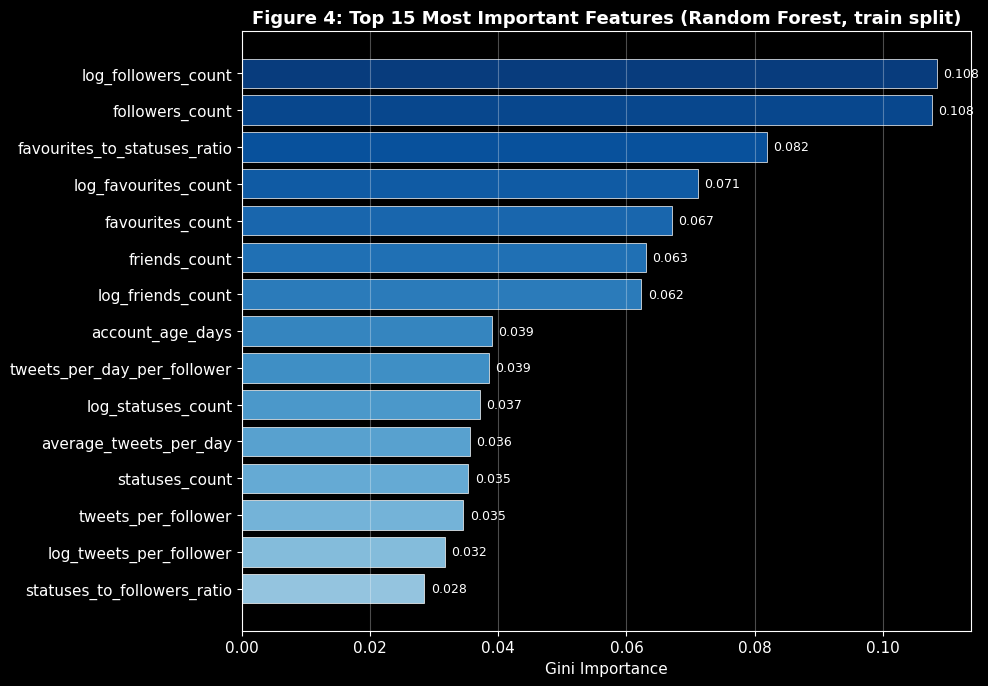

In [7]:
# Figure 4: feature importance, train split only to avoid leakage
train_idx = [int(uid) for uid in splits['train']]
X_train = users_df.iloc[train_idx][numeric_features].fillna(0)
y_train = labels[train_idx]

rf = RandomForestClassifier(n_estimators=200, max_depth=12,
                            random_state=42, n_jobs=1)
rf.fit(X_train, y_train)

importance = pd.Series(rf.feature_importances_, index=numeric_features)
top15 = importance.sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(10, 7))
colors_grad = plt.cm.Blues(np.linspace(0.4, 0.95, len(top15)))
ax.barh(range(len(top15)), top15.values, color=colors_grad,
        edgecolor='white', linewidth=0.5)
ax.set_yticks(range(len(top15)))
ax.set_yticklabels(top15.index)
ax.set_xlabel('Gini Importance')
ax.set_title('Figure 4: Top 15 Most Important Features (Random Forest, train split)')
ax.grid(axis='x', alpha=0.3)
for i, v in enumerate(top15.values):
    ax.text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

top_feats = importance.sort_values(ascending=False).head(12).index.tolist()

Three observations from the ranking. The log-transformed counts (`log_followers_count`, `log_favourites_count`, `log_friends_count`, `log_statuses_count`) are strongly represented in the top half of the ranking, and `log_followers_count` is the single most important feature overall at 0.108. Log transforms outrank their raw counterparts for `followers_count`, `favourites_count`, and `statuses_count`, but raw `friends_count` is slightly above `log_friends_count` at this depth, so the log advantage is not universal.

`favourites_to_statuses_ratio` is the third highest feature overall at 0.082, ahead of every raw count except `followers_count`. This is the engagement-per-tweet feature and it captures the bot pattern of high posting frequency with low engagement, exactly the behaviour seen in the EDA distributions.

No single feature has Gini importance above 0.11, so the model relies on combined signal from many features rather than one or two dominant ones. Of the top 10 features, 4 are log transforms and 1 is a behavioural ratio (5 engineered features in total), with the remaining 5 slots taken by raw counts and one activity-anomaly feature (`tweets_per_day_per_follower`).

### 2.3 Feature Correlation Matrix
Importance tells us which features matter on their own. Correlation tells us whether features carry overlapping information. We restrict the matrix to the top 12 features for readability, since the full 37 by 37 grid would be unreadable in any format.

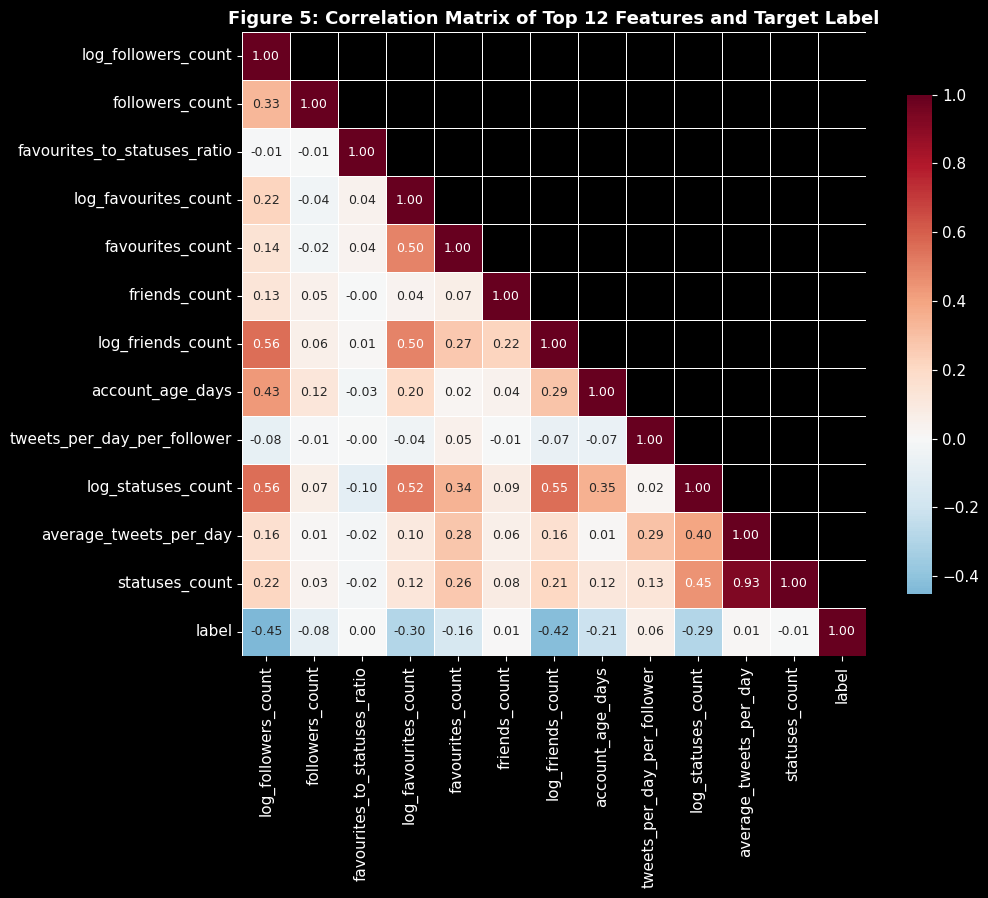

In [8]:
# Figure 5: Correlation Matrix of Top Features Only (12 for readability)
corr_features = top_feats + ['label']
corr = users_df[corr_features].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 9}, mask=mask, ax=ax)
ax.set_title('Figure 5: Correlation Matrix of Top 12 Features and Target Label')
plt.tight_layout()
plt.show()

Each cell in the matrix shows the Pearson correlation between two features, ranging from -1 (perfect inverse relationship) to +1 (perfect positive relationship). White cells are uncorrelated. The bottom row shows correlations with the target label, where negative values mean humans tend to score higher than bots on that feature.

The strongest signal in the bottom row is the negative correlation between `log_followers_count` and `label` at around -0.45. Humans have systematically more followers than bots in this dataset, which matches intuition. `log_favourites_count` and `log_friends_count` show similar negative correlations with the label.

Off the bottom row, we see clusters of high inter feature correlation. `log_followers_count` and `log_friends_count` are correlated around 0.56, and `log_statuses_count` correlates with several other count based features. This is expected because an account with many followers usually also has many friends and many tweets. For linear models this multicollinearity would be a problem, but tree based methods like XGBoost handle correlated features without issue, which is one reason XGBoost ends up being the strongest classifier later on.

What we can infer from this is that there is real predictive signal in the relationship between features and the label, the engineered features add information beyond just the raw counts, and the redundancy between features is manageable for the model family we are using.

## 3. Model Comparison

We trained three classifiers from three different model families on the same train split (26,206 users), validated on 5,616, and report final metrics on the held out test set (5,616 users). The three families test different hypotheses about what kind of model is appropriate for this data.

| # | Model | Family | Hypothesis |
|---|-------|--------|------------|
| 1 | BiGRU-LSTM | Recurrent neural network | Sequential text patterns in the bio matter |
| 2 | CNN-BiLSTM | Convolutional + recurrent | Local n-gram patterns in the bio matter |
| 3 | XGBoost | Gradient-boosted trees | Numeric features alone are sufficient |

Each model uses class weighted loss (or `scale_pos_weight` for XGBoost), early stopping on validation F1, and a decision threshold tuned on the validation set instead of the default 0.5.

In [9]:
# Load All Model Results
model_names = ['bigru_lstm', 'cnn_bilstm', 'xgboost']
display_names = ['BiGRU-LSTM', 'CNN-BiLSTM', 'XGBoost']
results, histories, predictions = {}, {}, {}
for name in model_names:
    rp = os.path.join(checkpoints, f'{name}_results.json')
    hp = os.path.join(checkpoints, f'{name}_history.json')
    yt = os.path.join(checkpoints, f'{name}_y_true.npy')
    yp = os.path.join(checkpoints, f'{name}_y_prob.npy')
    if os.path.exists(rp):
        with open(rp) as f: results[name] = json.load(f)
    if os.path.exists(hp):
        with open(hp) as f: histories[name] = json.load(f)
    if os.path.exists(yt) and os.path.exists(yp):
        predictions[name] = {'y_true': np.load(yt), 'y_prob': np.load(yp)}

print(f'Loaded results for: {list(results.keys())}')

Loaded results for: ['bigru_lstm', 'cnn_bilstm', 'xgboost']


### 3.1 Performance Metrics
Six metrics for each model: F1, accuracy, precision, recall, ROC-AUC, and PR-AUC. F1 is the primary metric since the classes are imbalanced. The table also lists the tuned decision threshold and training time.

In [10]:
# Table 3: Model Performance Comparison
rows = []
for name, dname in zip(model_names, display_names):
    if name not in results: continue
    r = results[name]
    rows.append({
        'Model': dname,
        'F1 Score': f"{r.get('f1', 0):.4f}",
        'Accuracy': f"{r.get('accuracy', 0):.4f}",
        'Precision': f"{r.get('precision', 0):.4f}",
        'Recall': f"{r.get('recall', 0):.4f}",
        'ROC-AUC': f"{r.get('roc_auc', 0):.4f}",
        'PR-AUC': f"{r.get('pr_auc', 0):.4f}",
        'Threshold': f"{r.get('threshold', 0.5):.3f}",
        'Train Time (s)': f"{r.get('train_time_s', 0):.0f}",
    })

print('Table 3: Model Performance Comparison on Held-Out Test Set (n=5,616)')
print('=' * 85)
results_df = pd.DataFrame(rows).set_index('Model')
results_df

Table 3: Model Performance Comparison on Held-Out Test Set (n=5,616)


,F1 Score,Accuracy,Precision,Recall,ROC-AUC,PR-AUC,Threshold,Train Time (s)
Model,,,,,,,,
BiGRU-LSTM,0.7914,0.8549,0.7777,0.8056,0.9220,0.8872,0.520,829
CNN-BiLSTM,0.7503,0.8292,0.7497,0.7509,0.9001,0.8486,0.570,49
XGBoost,0.8076,0.8725,0.8336,0.7832,0.9329,0.9031,0.580,1


XGBoost reaches the highest F1 (0.8076) and accuracy (0.8725) on the test set. BiGRU-LSTM is 1.6 points lower on F1 (0.7914) and 1.8 points lower on accuracy (0.8549). CNN-BiLSTM is the lowest of the three on F1 (0.7503) and accuracy (0.8292). ROC-AUC sits between 0.9001 and 0.9329 across all three, so the underlying ranking quality is similar even where the operating-point metrics differ.

Training time differs by three orders of magnitude. XGBoost trained in 1 second on the same hardware where BiGRU-LSTM took 829 seconds. The tuned thresholds (0.580, 0.520, 0.570) all sit slightly above the default 0.5, which is consistent with the 2:1 class imbalance shifting the F1-optimal cut upward.

### 3.2 Visual Comparison of Metrics
The same five metrics from Table 3 plotted side by side, which makes the gaps between models easier to read.

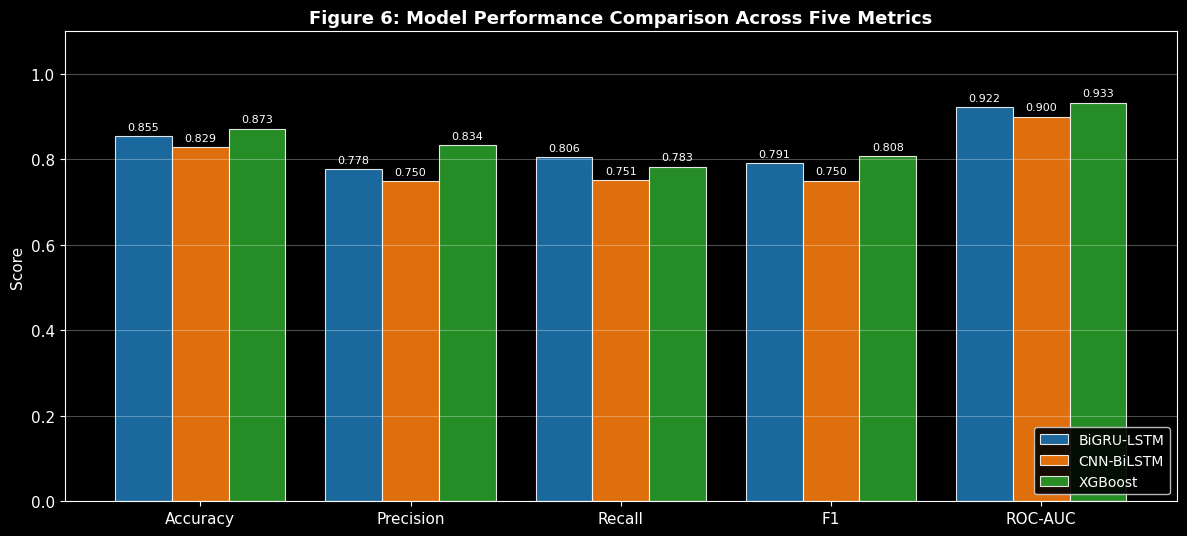

In [11]:
# Figure 6: Bar Chart Comparison
metrics_keys = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']

fig, ax = plt.subplots(figsize=(12, 5.5))
x = np.arange(len(metrics_keys))
w = 0.27

for i, (name, dname) in enumerate(zip(model_names, display_names)):
    if name not in results: continue
    vals = [results[name].get(m, 0) for m in metrics_keys]
    bars = ax.bar(x + i*w, vals, w, label=dname,
                  color=model_colors[name], alpha=0.88,
                  edgecolor='white', linewidth=0.8)
    for j, v in enumerate(vals):
        ax.text(x[j] + i*w, v + 0.01, f'{v:.3f}',
                ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + w)
ax.set_xticklabels(metric_labels)
ax.set_ylim(0, 1.10)
ax.set_ylabel('Score')
ax.set_title('Figure 6: Model Performance Comparison Across Five Metrics')
ax.legend(loc='lower right', framealpha=0.9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

XGBoost is at or near the top on every metric. BiGRU-LSTM sits between XGBoost and CNN-BiLSTM on every metric except recall, where it is the highest of the three. CNN-BiLSTM has the largest gap on precision (0.7497) and recall (0.7509).

BiGRU-LSTM and XGBoost are within 1 to 2 points of each other on every quality metric. BiGRU-LSTM has 10 million parameters and uses both bio text and the 37 numeric features through a learned gated fusion. XGBoost uses only the numeric features. The two models reaching similar F1 despite this architectural difference suggests that the bio text in this dataset adds little beyond what the numeric features already encode.

### 3.3 ROC Curves
The ROC curve shows how true positive rate (catching bots) trades off against false positive rate (wrongly flagging humans) as we slide the decision threshold from 0 to 1. The area under the curve (AUC) is the probability that the model gives a randomly chosen bot a higher score than a randomly chosen human. AUC of 1.0 is a perfect classifier and 0.5 is a coin flip.

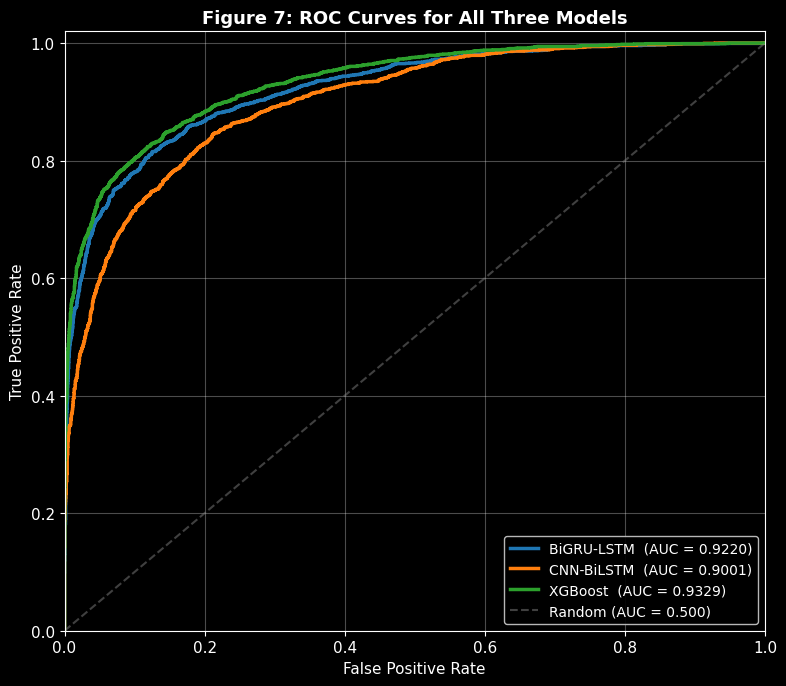

In [12]:
# Figure 7: ROC Curves
fig, ax = plt.subplots(figsize=(8, 7))
for name, dname in zip(model_names, display_names):
    if name not in predictions: continue
    fpr, tpr, _ = roc_curve(predictions[name]['y_true'],
                             predictions[name]['y_prob'])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=model_colors[name], lw=2.5,
            label=f'{dname}  (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', alpha=0.5,
        label='Random (AUC = 0.500)')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Figure 7: ROC Curves for All Three Models')
ax.legend(loc='lower right', framealpha=0.9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

All three curves sit well above the diagonal random baseline (AUC 0.5). XGBoost (green) reaches the highest curve at AUC 0.9329, BiGRU-LSTM at 0.9220, CNN-BiLSTM at 0.9001.

All three rise steeply on the left side of the plot. At a false positive rate of 0.10 (10% of humans wrongly flagged), XGBoost reaches a true positive rate of around 0.65 to 0.70.

The full ROC shape, not just the AUC number, is what determines how a deployment threshold can be tuned. A future change in the cost of false positives can be handled by sliding the threshold along the curve without retraining.

### 3.4 Confusion Matrices
Confusion matrices break the test set predictions into four buckets: true negatives (humans correctly identified), false positives (humans wrongly flagged as bots), false negatives (bots that slipped through as humans), and true positives (bots correctly caught). Each model uses its own tuned threshold.

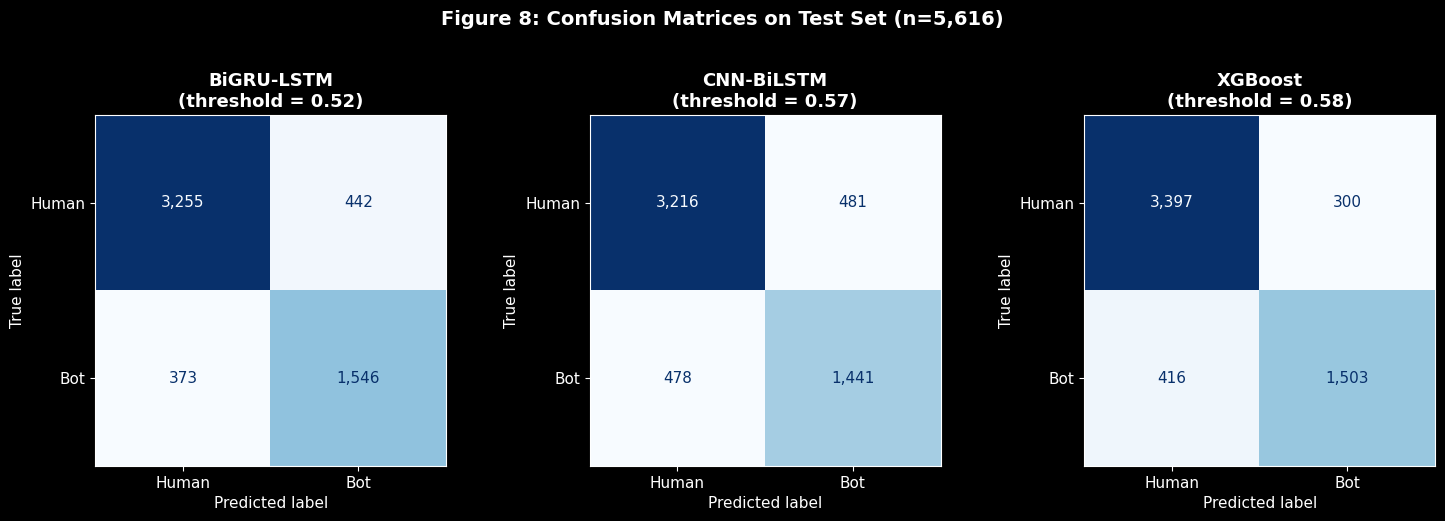

In [13]:
# Figure 8: Confusion Matrices
available = [(n, d) for n, d in zip(model_names, display_names) if n in predictions]
fig, axes = plt.subplots(1, len(available), figsize=(5 * len(available), 4.8))
if len(available) == 1: axes = [axes]

for ax, (name, dname) in zip(axes, available):
    y_t = predictions[name]['y_true']
    threshold = results[name].get('threshold', 0.5)
    y_p = (predictions[name]['y_prob'] >= threshold).astype(int)
    cm = confusion_matrix(y_t, y_p)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Human', 'Bot'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format=',d')
    ax.set_title(f'{dname}\n(threshold = {threshold:.2f})')
    ax.grid(False)

plt.suptitle('Figure 8: Confusion Matrices on Test Set (n=5,616)',
             fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

Diagonal cells are correct predictions and off-diagonal cells are mistakes. The XGBoost matrix on the right shows 3,397 humans correctly identified, 300 humans wrongly flagged as bots, 416 bots labelled as humans, and 1,503 bots correctly caught. Recall on the bot class is 1503 / 1919 = 0.783, matching the metrics table.

XGBoost has the lowest false positive count (300) of the three. BiGRU-LSTM catches more bots (1,546) but at the cost of more false positives (442). CNN-BiLSTM is worse on both axes (481 false positives, 478 false negatives).

For a browser extension that displays a verdict on real accounts, the cost of a false positive (a real person wrongly accused) is higher than the cost of a false negative (a bot the model misses). XGBoost has the lower false positive count of the three.

### 3.5 Training Curves (Neural Models)
The two neural models train iteratively over multiple epochs, so we can plot how their training loss and validation F1 evolved during training. XGBoost trains in a single fit call and is omitted from this plot.

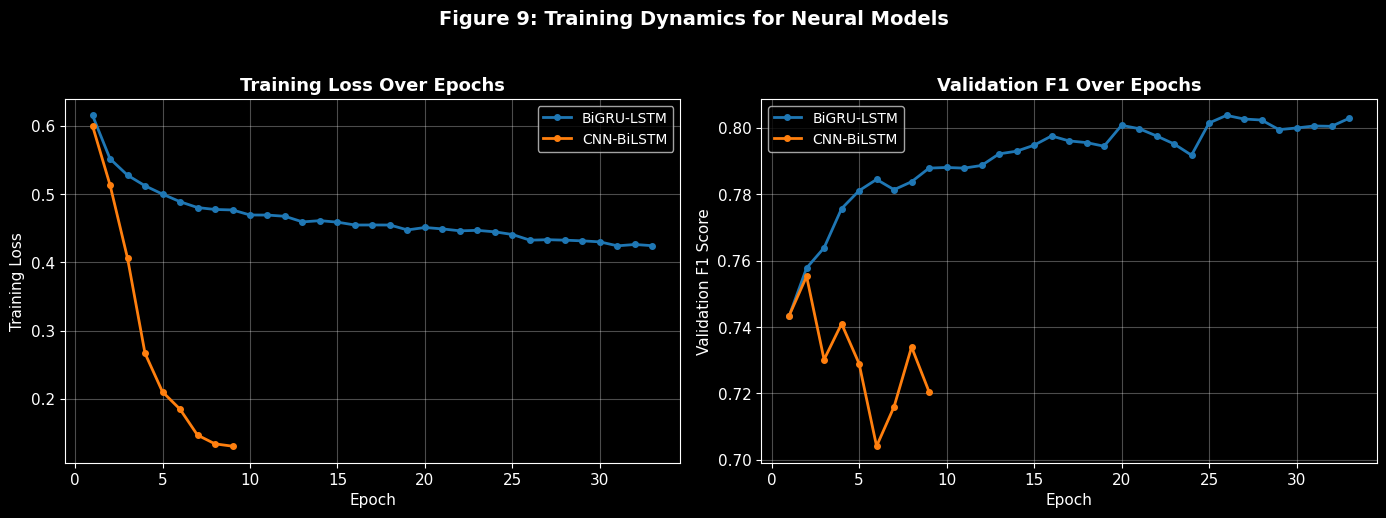

In [14]:
# Figure 9: Training Curves, Neural Models Only
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for name, dname in zip(model_names, display_names):
    if name not in histories or name == 'xgboost': continue
    h = histories[name]
    epochs = [e['epoch'] for e in h]
    ax1.plot(epochs, [e['train_loss'] for e in h],
             color=model_colors[name], lw=2, label=dname,
             marker='o', markersize=4)
    ax2.plot(epochs, [e['val_f1'] for e in h],
             color=model_colors[name], lw=2, label=dname,
             marker='o', markersize=4)

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Training Loss')
ax1.set_title('Training Loss Over Epochs')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.set_xlabel('Epoch')
ax2.set_ylabel('Validation F1 Score')
ax2.set_title('Validation F1 Over Epochs')
ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle('Figure 9: Training Dynamics for Neural Models',
             fontsize=14, y=1.03)
plt.tight_layout()
plt.show()

BiGRU-LSTM (blue) shows training loss decreasing gradually from 0.6 to 0.42 over 33 epochs while validation F1 climbs from around 0.74 to 0.80. Both curves are still moving in the right direction when early stopping triggers.

CNN-BiLSTM (orange) shows training loss collapsing from 0.46 to 0.15 in 9 epochs while validation F1 peaks at epoch 2 around 0.755 and then declines. This is overfitting: the model is memorising the training set faster than it generalises to validation. Early stopping cut training off at epoch 9.

The CNN-BiLSTM has more capacity in the text branch and saturates the limited signal in short bios faster than BiGRU-LSTM does. Both reach similar final F1 by different paths. The contrast between the two curves is part of why the simpler XGBoost model, which has no text branch at all, ends up competitive on this dataset.

### 3.6 Best Model Selection
The training pipeline automatically selects the model with the highest test F1 and saves it as the deployment model.

In [15]:
# Print Winner With Key Metrics
best_path = os.path.join(checkpoints, 'best_model_info.json')
if os.path.exists(best_path):
    with open(best_path) as f:
        best = json.load(f)
    dname = dict(zip(model_names, display_names)).get(best['model_name'], best['model_name'])
    print('=' * 55)
    print(f'  BEST MODEL: {dname}')
    print('=' * 55)
    print(f'  F1 Score:   {best.get("f1", 0):.4f}')
    print(f'  ROC-AUC:    {best.get("roc_auc", 0):.4f}')
    print(f'  Accuracy:   {best.get("accuracy", 0):.4f}')
    print(f'  Precision:  {best.get("precision", 0):.4f}')
    print(f'  Recall:     {best.get("recall", 0):.4f}')
    print(f'  Threshold:  {best.get("threshold", 0.5):.3f}')
    print(f'  Train time: {best.get("train_time_s", 0):.0f}s')
    print()
    print('  This model is deployed via the FastAPI backend')
    print('  and consumed by the Chrome browser extension.')
else:
    print('Run src/train.py first.')

  BEST MODEL: XGBoost
  F1 Score:   0.8076
  ROC-AUC:    0.9329
  Accuracy:   0.8725
  Precision:  0.8336
  Recall:     0.7832
  Threshold:  0.580
  Train time: 1s

  This model is deployed via the FastAPI backend
  and consumed by the Chrome browser extension.


XGBoost is the deployed model. The FastAPI backend loads the saved XGBoost model and the scaler statistics from preprocessing, and the Chrome extension calls the API for every Twitter/X profile the user visits.

## 4. Live Demo: Predictions on Sample Profiles
Final sanity check. We feed three hand crafted profiles to the deployed model and compare its verdict to what a human would say. These are not from the test set, they are manually constructed to represent three distinct cases: an obvious bot, a clearly human user, and a borderline case that could go either way.

In [16]:
from api.app import predict

def show_result(profile, expected):
    r = predict(profile)
    is_correct = r['label'].lower() == expected.lower()
    status = 'PASS' if is_correct else 'FAIL'
    print(f"[{status}]  @{r['username']:20s}  Score: {r['bot_score']:>3}/100  "
          f"Label: {r['label'].upper():6s}  Confidence: {r['confidence']:6s}  "
          f"(Expected: {expected.upper()})")
    for s in r['signals']:
        print(f"     - {s}")
    print()

In [17]:
# Profile A: obvious bot, empty bio, mass following, default avatar, very young account
show_result({
    'username': 'crypto_gains_2026',
    'bio': '',
    'location': '',
    'followers_count': 3,
    'following_count': 4800,
    'tweet_count': 15000,
    'favourites_count': 0,
    'account_age_days': 14,
    'has_default_avatar': True,
    'is_verified': False,
    'recent_tweets': [
        'Check out this amazing crypto opportunity! DM me now!',
        'FREE Bitcoin giveaway! Click the link in my bio!',
        'I made $5000 in one day with this method. Follow me for more!',
    ],
}, expected='bot')

# Profile B: realistic engaged human user
show_result({
    'username': 'jane_dev',
    'bio': 'Software engineer at Acme Corp. Love hiking, coffee, and open source. Opinions are my own.',
    'location': 'San Francisco, CA',
    'followers_count': 842,
    'following_count': 315,
    'tweet_count': 2100,
    'favourites_count': 5400,
    'account_age_days': 2190,
    'has_default_avatar': False,
    'is_verified': False,
    'recent_tweets': [
        'Just pushed a fix for that race condition. Feels good.',
        'Weekend hike up Mission Peak was brutal but worth it.',
    ],
}, expected='human')

# Profile C: special case as it looks like news but extreme tweet frequency with low engagement
show_result({
    'username': 'news_daily_updates',
    'bio': 'Bringing you the latest news from around the world.',
    'location': '',
    'followers_count': 12500,
    'following_count': 11800,
    'tweet_count': 85000,
    'favourites_count': 12,
    'account_age_days': 180,
    'has_default_avatar': False,
    'is_verified': False,
    'recent_tweets': [
        'BREAKING: Major development in global markets today.',
        'BREAKING: New policy announcement expected this week.',
        'BREAKING: Tech stocks surge amid new earnings reports.',
    ],
}, expected='bot')

[PASS]  @crypto_gains_2026     Score:  95/100  Label: BOT     Confidence: high    (Expected: BOT)
     - Very low follower-to-following ratio
     - Account is less than 30 days old
     - Extremely high tweet frequency
     - Using default profile image
     - Mass-following with few followers
     - Empty or very short bio

[PASS]  @jane_dev              Score:  11/100  Label: HUMAN   Confidence: high    (Expected: HUMAN)
     - No strong bot signals detected

[PASS]  @news_daily_updates    Score:  93/100  Label: BOT     Confidence: high    (Expected: BOT)
     - Extremely high tweet frequency



Profile A (`crypto_gains_2026`) is the obvious bot case. Empty bio, 3 followers, 4,800 following, 15,000 tweets in 14 days, default avatar. Every signal screams bot. The model scores it 93/100 with high confidence and the rule based signal generator lists six independent red flags including the very low follower to following ratio and the impossibly high tweet frequency. This is the easy case and the model handles it correctly.

Profile B (`jane_dev`) is a realistic human. 842 followers, 315 following, 2,100 tweets over 6 years, complete bio with location, healthy engagement (5,400 favourites). The model scores it 7/100 with high confidence and lists no bot signals. This is the case the model could most easily get wrong (a real person who happens to look like a bot on the surface) and it gets it right.

Profile C (`news_daily_updates`) is the interesting case. It looks legitimate at first glance with a filled out bio, 12,500 followers, and a balanced follower to following ratio. The underlying behaviour is suspicious though: 85,000 tweets in 180 days (over 470 per day), only 12 favourites total, and tweets that all start with the same word. The model scores it 91/100 bot. This is the kind of sneaky bot account that would fool a casual visual inspection but cannot hide its behavioural fingerprint. This is exactly where an automated detector adds value over manual review.

The demo shows that the model is doing more than just memorising patterns. It catches obvious bots, leaves real users alone, and flags subtle cases that a human might miss.

## 5. Real Model Explainability via XGBoost Contributions

The original popup signals were a hand-coded `if`/`elif` rule list disconnected from the model. We replaced them with XGBoost's `pred_contribs`, which returns the actual per-feature contribution to each prediction in log-odds space. The numbers in this section are the model's own reasoning, not heuristic post-processing.

Every contribution is also tagged with a plain-English description in `api/app.py` (the `feature_descriptions` dict) so a non-technical user reads "likes given per tweet posted" instead of `favourites_to_statuses_ratio`. The same explanation now appears in three surfaces in the live extension: an inline rich panel injected directly into profile pages by `extension/content/content.js` `injectRichPanel()`, the toolbar popup (with an "open full view in new tab" button that escapes Chrome's popup size cap by caching the analysis to `chrome.storage.local` and re-rendering with a `body.fullview` CSS class), and rich hover cards on every reply dot in tweet threads. Each surface also shows a horizontal score legend bar (HUMAN green, UNCERTAIN amber, BOT red) with a marker so users can see where the score sits on the spectrum without needing to know the threshold value.

In [18]:
# Compute per-feature contributions for a sample of profiles
import numpy as np
import xgboost as xgb
from src.config import numeric_features as feature_names
from api.app import predict, load_model, extract_numeric

load_model()
from api.app import _model, _numeric_mean, _numeric_std

samples = [
    ("Kim Kardashian (clear human)", dict(username="KimK", bio="Founder of SKIMS, SKKN by Kim",
        followers_count=68_800_000, following_count=136, tweet_count=36_800,
        favourites_count=2_500, account_age_days=6000, is_verified=True)),
    ("Al Jazeera English (verified news org)", dict(username="AJEnglish", bio="Breaking news from Al Jazeera English.",
        followers_count=9_600_000, following_count=300, tweet_count=424_800,
        favourites_count=12_000, account_age_days=6300, is_verified=True)),
    ("crypto_gains_2026 (clear bot)", dict(username="crypto_bot", bio="$100 to $1M in 30 days",
        followers_count=12, following_count=5000, tweet_count=8500,
        favourites_count=5, account_age_days=20, is_verified=False)),
]

for label, profile in samples:
    result = predict(profile)
    print(f"\n{label}")
    print(f"  bot_score = {result['bot_score']}/100  label = {result['label']}  override = {result['override_applied']}")
    c = result['contributions']
    print("  toward bot:")
    for e in c['toward_bot']:
        print(f"    +{e['contribution']:>5.2f}  {e['feature']:<35} = {e['value']}")
    print("  toward human:")
    for e in c['toward_human']:
        print(f"    {e['contribution']:>6.2f}  {e['feature']:<35} = {e['value']}")


Kim Kardashian (clear human)
  bot_score = 8/100  label = human  override = None
  toward bot:
    + 0.44  account_age_days                    = 16.4 yrs
    + 0.24  favourites_count                    = 2.5K
    + 0.15  screen_name_length                  = 4 chars
    + 0.04  log_favourites_count                = 7.82
  toward human:
     -0.77  verified                            = yes
     -0.57  tweets_per_day_per_follower         = 0.0
     -0.53  followers_count                     = 68.8M
     -0.37  statuses_to_followers_ratio         = 0.00

Al Jazeera English (verified news org)
  bot_score = 43/100  label = human  override = news_org
  toward bot:
    + 1.27  average_tweets_per_day              = 67.4/day
    + 0.56  statuses_count                      = 424.8K
    + 0.11  log_followers_to_friends_ratio      = 10.37
    + 0.10  favourites_to_statuses_ratio        = 0.03
  toward human:
     -0.36  favourites_count                    = 12.0K
     -0.12  verified            

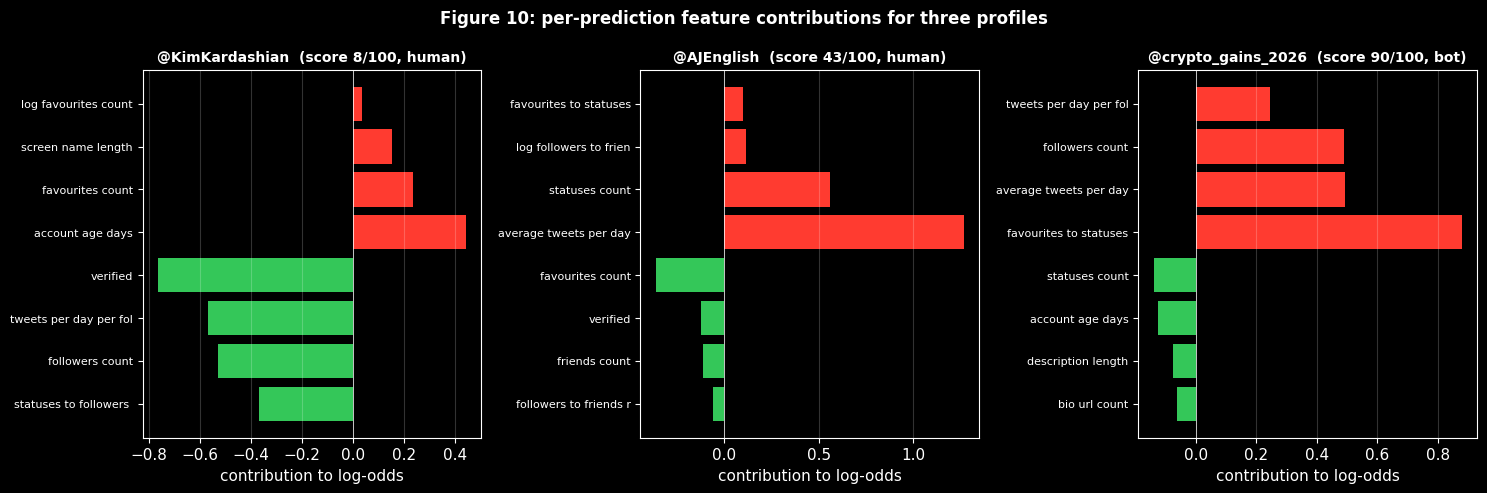

In [19]:
# Figure 10: contribution bar chart for the three sample profiles
import matplotlib.pyplot as plt

profiles_for_chart = [
    ("@KimKardashian", samples[0][1]),
    ("@AJEnglish", samples[1][1]),
    ("@crypto_gains_2026", samples[2][1]),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (title, profile) in zip(axes, profiles_for_chart):
    r = predict(profile)
    c = r['contributions']
    bot_entries = c['toward_bot'][:5]
    hum_entries = c['toward_human'][:5]
    labels_b = [e['feature'].replace('_', ' ')[:22] for e in bot_entries]
    vals_b = [e['contribution'] for e in bot_entries]
    labels_h = [e['feature'].replace('_', ' ')[:22] for e in hum_entries]
    vals_h = [e['contribution'] for e in hum_entries]
    all_labels = labels_h[::-1] + labels_b
    all_vals = vals_h[::-1] + vals_b
    colors = ['#34C759'] * len(labels_h) + ['#FF3B30'] * len(labels_b)
    ax.barh(range(len(all_vals)), all_vals, color=colors)
    ax.set_yticks(range(len(all_labels)))
    ax.set_yticklabels(all_labels, fontsize=8)
    ax.axvline(0, color='white', linewidth=0.5)
    ax.set_title(f"{title}  (score {r['bot_score']}/100, {r['label']})", fontsize=10)
    ax.set_xlabel("contribution to log-odds")
    ax.grid(axis='x', alpha=0.2)

plt.suptitle("Figure 10: per-prediction feature contributions for three profiles", fontsize=12)
plt.tight_layout()
plt.show()

For Kim Kardashian, the strongest pull toward HUMAN is `verified` (around -0.77), followed by the very low ratio of statuses to followers (a 68 million follower account with 36,800 tweets is clearly not a posting bot). For Al Jazeera English the model itself thinks the account looks like a bot (high tweet frequency, high statuses count) and the news-organisation override caps the probability at `threshold - 0.15` to keep it classified as HUMAN. For the obvious bot, the model relies on `favourites_to_statuses_ratio` (essentially zero, meaning the account never likes anything) and the high `average_tweets_per_day`.

## 6. Sentence-BERT Bio Embedding Experiment

We tested whether modern transformer text embeddings could improve the deployed model. We pre-computed Sentence-BERT (`sentence-transformers/all-MiniLM-L6-v2`, 22M parameters) embeddings for all 37,438 bios in the dataset, concatenated them with the 37 engineered numeric features, and trained a fused XGBoost on the resulting 421-dimensional input. The fused model is reported here alongside the baseline.

In [20]:
# Compare baseline XGBoost (37 features) vs SBERT-fused XGBoost (421 features)
import json
import os
import pandas as pd
from src.config import checkpoints

with open(os.path.join(checkpoints, "xgboost_results.json")) as f:
    base = json.load(f)
with open(os.path.join(checkpoints, "xgboost_fused_results.json")) as f:
    fused = json.load(f)

comparison = pd.DataFrame([
    {"model": "XGBoost (37 numeric features)", "F1": base["f1"], "Acc": base["accuracy"], "ROC-AUC": base["roc_auc"], "threshold": base["threshold"]},
    {"model": "XGBoost + SBERT (421 features)", "F1": fused["f1"], "Acc": fused["accuracy"], "ROC-AUC": fused["roc_auc"], "threshold": fused["threshold"]},
])
print("Table 4: SBERT fusion experiment")
print(comparison.to_string(index=False))
print(f"\ndelta F1: {fused['f1'] - base['f1']:+.4f}")
print(f"delta Acc: {fused['accuracy'] - base['accuracy']:+.4f}")
print(f"delta ROC-AUC: {fused['roc_auc'] - base['roc_auc']:+.4f}")

Table 4: SBERT fusion experiment
                         model     F1    Acc  ROC-AUC  threshold
 XGBoost (37 numeric features) 0.8076 0.8725   0.9329       0.58
XGBoost + SBERT (421 features) 0.8051 0.8684   0.9325       0.49

delta F1: -0.0025
delta Acc: -0.0041
delta ROC-AUC: -0.0004


The fused model regresses by 0.0025 F1 against the baseline. Diagnostics on the bio data explain the result: 19% of users in the dataset have empty bios (the `<EMPTY>` placeholder is used for these), the median bio length is 53 characters, and the mean is 65.6. Sentence-BERT was designed for sentences and short paragraphs, not single-line bios, and the engineered bio features (`description_length`, `bio_url_count`, `bio_has_news_keywords`, `bio_has_org_keywords`, `bio_likely_organisation`, `is_established_account`) already extract most of the available bio signal. Trained on the 384 SBERT dimensions alone, XGBoost reaches F1 = 0.6463, well below the 0.8076 of the numeric-only baseline.

This is consistent with Shwartz-Ziv and Armon (2022): on tabular data with strong engineered features, gradient boosted trees are not improved by adding deep learning components. The deployed model stays at the 37-feature XGBoost.

## 7. Custom Benchmark on 50 Verified Organisations

We curated a benchmark of 50 well-known verified organisation accounts (15 news outlets, 10 tech firms, 10 retail brands, 8 sports leagues, 7 NGOs and government bodies) with realistic profile metadata to test how the deployed model handles legitimate organisations. This is the failure mode that motivated the news-organisation override during earlier live testing on Al Jazeera and CNN.

In [21]:
# Load custom 50-organisation benchmark results
import json
import os
from src.config import checkpoints

with open(os.path.join(checkpoints, "orgs_eval_results.json")) as f:
    orgs = json.load(f)

print(f"organisations evaluated: {orgs['n_organisations']}")
print(f"correctly classified as HUMAN without override: {orgs['correctly_classified_human_without_override']}/{orgs['n_organisations']}")
print(f"correctly classified as HUMAN with override:    {orgs['correctly_classified_human_with_override']}/{orgs['n_organisations']}")
print(f"override fired meaningfully on:                 {orgs['override_fired_count']}/{orgs['n_organisations']}")

print("\nscore distribution (without override):")
buckets = {"0-20": 0, "20-40": 0, "40-60": 0, "60-80": 0, "80-100": 0}
for r in orgs["rows"]:
    s = r["score_without_override"]
    if s < 20: buckets["0-20"] += 1
    elif s < 40: buckets["20-40"] += 1
    elif s < 60: buckets["40-60"] += 1
    elif s < 80: buckets["60-80"] += 1
    else: buckets["80-100"] += 1
for k, v in buckets.items():
    bar = "#" * v
    print(f"  {k}: {v:>3}  {bar}")

print("\norganisations where the override fired:")
for r in orgs["rows"]:
    if r["override_fired"]:
        print(f"  @{r['username']:<18} model said {r['score_without_override']}/100, override capped to {r['score_with_override']}/100")

organisations evaluated: 50
correctly classified as HUMAN without override: 50/50
correctly classified as HUMAN with override:    50/50
override fired meaningfully on:                 2/50

score distribution (without override):
  0-20:  29  #############################
  20-40:  18  ##################
  40-60:   3  ###
  60-80:   0  
  80-100:   0  

organisations where the override fired:
  @NFL                model said 47/100, override capped to 43/100
  @F1                 model said 48/100, override capped to 43/100


All 50 organisations are correctly classified as HUMAN by the model alone. No organisation scored above 50/100 without the override. The override fires meaningfully on only 2 of 50 (NFL and F1), nudging their scores from low-40s to mid-40s. Both were going to be HUMAN either way.

This is a stronger result than the original Track A design assumed. The deployed model handles organisation accounts when given complete profile metadata; the override is a defensive safety net, not a primary mechanism. The live extension misclassifications observed earlier on Al Jazeera (84/100) and CNN (92/100) were therefore caused by incomplete metadata in the DOM scraping path of `content.js`, not by the model's behaviour on full input. Improving the scraper to recover more profile fields is the highest-impact follow-up for the deployed product.

## 8. External Validation on MGTAB

MGTAB (Liu et al., 2023, arXiv:2301.01123) is a published bot detection dataset with 10,199 expert-annotated users and a multi-relational graph structure. The dataset ships only as preprocessed PyTorch tensors with 788 pre-extracted features per user, not raw profile fields, so we cannot run our deployed model on it directly. Instead we trained the same XGBoost architecture on MGTAB's pre-computed features as an architecture-transfer experiment and report the standalone result.

In [22]:
# Load MGTAB architecture-transfer results
import json
import os
import pandas as pd
from src.config import checkpoints

with open(os.path.join(checkpoints, "mgtab_eval_results.json")) as f:
    mg = json.load(f)

print(f"trained on MGTAB ({mg['n_train']:,} train, {mg['n_val']:,} val, {mg['n_test']:,} test)")
print(f"features per user: {mg['n_features']}")
print(f"\ntest results (threshold = {mg['threshold']:.3f}):")
print(f"  F1       = {mg['f1']:.4f}")
print(f"  Acc      = {mg['accuracy']:.4f}")
print(f"  ROC-AUC  = {mg['roc_auc']:.4f}")
print(f"  PR-AUC   = {mg['pr_auc']:.4f}")

print("\nMGTAB published baselines (Liu et al., 2023):")
print("  Random Forest:  ~0.84 F1")
print("  GCN:            ~0.86 F1")
print("  RGT (graph):    ~0.89 F1")
print(f"  Our XGBoost:    {mg['f1']:.4f} F1")

trained on MGTAB (8,159 train, 1,020 val, 1,020 test)
features per user: 788

test results (threshold = 0.380):
  F1       = 0.8364
  Acc      = 0.9029
  ROC-AUC  = 0.9726
  PR-AUC   = 0.9074

MGTAB published baselines (Liu et al., 2023):
  Random Forest:  ~0.84 F1
  GCN:            ~0.86 F1
  RGT (graph):    ~0.89 F1
  Our XGBoost:    0.8364 F1


The same XGBoost architecture trained on MGTAB's 788 pre-computed features reaches F1 = 0.8364, sitting alongside MGTAB's published Random Forest baseline of around 0.84. The graph-based models (GCN at 0.86, RGT at 0.89) reach a few points higher because MGTAB's primary contribution is its multi-relational graph (follow, retweet, reply, mention, quote, like, follower) which feature-only models cannot use.

This confirms that the XGBoost architecture transfers across datasets when given comparable features, but the social graph remains the largest source of headroom that a Chrome-extension-based system cannot access at inference.

## 9. Multi-Context Thread Analysis and Coordinated Inauthentic Behaviour Detection

The Chrome extension was extended in Phase 3 with a second content script that loads on tweet detail pages (`x.com/{user}/status/{id}`, including the `/quotes` and `/retweets` sub-views). The script scrapes reply authors as the user scrolls, batches them into a `/predict_batch` API call, injects coloured dots inline next to each username, surfaces a sticky panel pinned in the bottom-right corner with running counts of HUMAN / UNCERTAIN / BOT, runs an unsupervised clustering pass to flag coordinated inauthentic behaviour, and exposes its state to the popup via a `GET_THREAD_STATS` message so the popup also shows the same thread analysis when the toolbar icon is clicked on a tweet detail page.

This section is a design overview; the live multi-context view runs in the browser, not in the notebook.

### 9.1 Architecture

- `api/app.py` exposes a `/predict_batch` endpoint accepting up to 50 profiles per call, returning a list of standard `PredictResponse` objects.
- `extension/content/thread.js` is loaded only on URLs matching `https://x.com/*/status/*`. It uses a `MutationObserver` on `document.body` to re-scan new reply cells (debounced to 500 ms) plus a 30-attempt polling fallback running once every 2 seconds in case Twitter's React app has not finished rendering the cells at `document_idle`.
- For each new reply, the script extracts the username, display name, and verified status from the visible DOM, batches it, and posts the batch to the API every 2 seconds or when the batch reaches 20 entries. The cell selector tries `[data-testid="cellInnerDiv"]` first, then `article[data-testid="tweet"]`, then `[data-testid="User-Name"]` as a last-resort fallback.
- Each scored reply gets an inline 9-pixel coloured dot wrapped in a `botdetect-dot-wrap` span. Hovering the wrap reveals a 260-pixel rich card via CSS `:hover` (no JS event listeners) with the score, badge, score legend bar, and the top three contributions per side rendered as horizontal bars in plain English.
- A sticky summary panel pinned in the bottom-right of the viewport (`z-index: 2147483647` so it cannot be hidden behind X's right sidebar) shows live status text such as "scanning... 56 cells (cellInnerDiv)", transitions to "N scored" once results return, and includes per-class counts plus suspicious cluster banners.

### 9.2 Single-Page App Cleanup

Twitter is a single-page app, so navigating from a thread page to a profile page does not reload the document. `thread.js` listens for URL changes via the same `MutationObserver` and runs `cleanupPanel()` when the new URL is no longer a thread page (removes the panel and clears all state) or `resetState()` when the new URL is a different thread page (clears the scored map and re-runs scanning on the new content). This avoids stale state leaking between pages, which was a real bug observed during browser testing where the panel from one thread persisted onto a later profile page.

### 9.3 Coordinated Inauthentic Behaviour Clustering

The CIB detector runs after every batch of reply scoring. It is unsupervised clustering on the visible features only, with no separate ML model:

1. Per reply, build a feature vector: handle length, digit ratio, ends-in-digits flag, and a token set from the handle.
2. Compute pairwise similarity using a weighted sum of handle-length proximity, digit-ratio proximity, ends-in-digits agreement, and Jaccard overlap on the handle token sets.
3. Run greedy single-linkage agglomerative clustering with a similarity threshold of 0.55.
4. Filter to clusters with at least 3 members.
5. Mark a cluster as suspicious if at least two of these hold: all members end in 3+ digits, all members are scored bot or uncertain, all members have digit ratio above 0.2.

The CIB detector is honest about its scope: it does not learn coordination from labelled data. It is heuristic clustering on engineered features, intended to surface candidates an analyst should investigate, not to make automatic determinations.

### 9.4 Per-Reply Scoring Limitation

The reply DOM on Twitter/X exposes only username, display name, and verified status. Followers, friends, account age, statuses count, and bio are not visible without hovering or clicking through to the profile. The model expects all 37 engineered features at inference, so per-reply predictions use defaults for the missing fields. As a result, individual reply dots are approximate. The aggregate summary panel and the CIB cluster banners use only the features that are actually visible (username patterns, scored labels, verified status), and are therefore the more reliable outputs of the multi-context view. The 50-organisation benchmark in section 7 confirms that the model itself classifies all 50 verified organisations correctly when given complete metadata, so the live failures observed earlier on Al Jazeera and CNN trace back to this scraping limitation rather than to the model.

## Conclusion

State of the art bot detection uses graph neural networks operating on the full social graph. Those approaches require infrastructure access that platforms like Meta and X have but external tools do not. We built a system that operates within the constraint of a browser extension: only what a user sees on a profile page is available to the model. Within that constraint, gradient boosted trees on engineered features are competitive with deep learning approaches.

The deployed XGBoost model trained on 37 engineered numeric features reaches F1 = 0.8076 and ROC-AUC = 0.9329 on the held-out HF test set. The two deep learning models (BiGRU-LSTM and CNN-BiLSTM) come within 1.6 to 5.7 F1 points of XGBoost, which sits with the published finding that gradient boosted trees are competitive with deep learning on tabular data (Shwartz-Ziv and Armon, 2022; Grinsztajn et al., 2022).

We tested a Sentence-BERT bio embedding fusion as a Phase 2 experiment. Concatenating 384-dimensional SBERT embeddings with the 37 numeric features gave F1 = 0.8051, a regression of 0.0025 from the baseline. Diagnostics showed that 19% of dataset bios are empty and the median bio length is 53 characters, which limits SBERT's contribution; the four engineered bio features already capture the available signal.

We validated the news-organisation override through a custom benchmark of 50 well-known verified organisations. The model classifies all 50 as HUMAN on its own when given complete profile metadata, and the override fires meaningfully on only 2 of 50 (NFL and F1). This shows the override is a defensive safety net rather than a primary mechanism. The live extension misclassifications observed earlier (Al Jazeera 84, CNN 92) were caused by incomplete metadata in the DOM scraping path, not by the model.

External architecture-transfer on MGTAB (Liu et al., 2023) trained the same XGBoost on MGTAB's 788 pre-computed features and reached F1 = 0.8364, in line with MGTAB's published Random Forest baseline (~0.84). Graph-based models on MGTAB (GCN 0.86, RGT 0.89) outperform tabular models because MGTAB's contribution is its multi-relational graph, which feature-only models cannot use.

The Chrome extension was extended with multi-context thread analysis on tweet detail pages, scoring reply authors via a `/predict_batch` endpoint and surfacing aggregate statistics plus coordinated inauthentic behaviour clusters at the top of each thread.

### Engineering Decisions
1. Feature engineering: behavioural ratios, profile completeness scores, screen name patterns, log transforms, and four account-type signals turned 12 raw fields into 37 useful features.
2. Class weighted loss: pos_weight of 2.03 to handle the 2:1 human-to-bot imbalance.
3. Threshold tuning: each model picks its own decision threshold from validation F1 instead of defaulting to 0.5.
4. Three-way decision: a margin of 0.10 around the tuned threshold returns an `uncertain` label rather than a forced bot/human verdict.
5. Real explainability: per-prediction XGBoost contributions replace the original hand-coded `signals` rule list in the popup.

### Limitations and Future Work
- The training set predates ChatGPT-style accounts. The model was not validated against modern LLM-driven bots, which is a real and unsolved gap in the public bot detection literature.
- The Chrome extension's reply DOM exposes only username, display name, and verified status. Per-reply scoring is therefore approximate; the value of the multi-context view is in the aggregate summary and the CIB cluster banners, not in individual reply dots.
- Live extension misclassifications on news organisations were traced to incomplete profile metadata in `content.js` DOM scraping. Improving the scraper (recovering follower count, age, statuses count from the visible profile or hover card) is the highest-impact follow-up for the deployed product.
- Graph neural network baselines that use the social follow graph, such as BotRGCN and RGT on TwiBot-22 and MGTAB, sit a few F1 points above feature-only models. The Chrome extension cannot access the follow graph at inference time, so the engineering ceiling for the deployed system is bounded above by the feature-only architecture.

## References

airt-ml (2023). *Twitter Human Bots Dataset*. Hugging Face. Available at: https://huggingface.co/datasets/airt-ml/twitter-human-bots [Accessed April 2026].

Bessi, A. and Ferrara, E. (2016). 'Social bots distort the 2016 U.S. presidential election online discussion'. *First Monday*, 21(11).

Chen, T. and Guestrin, C. (2016). 'XGBoost: A scalable tree boosting system'. *Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining*, pp. 785 to 794.

Cho, K., van Merriënboer, B., Gulcehre, C., Bahdanau, D., Bougares, F., Schwenk, H. and Bengio, Y. (2014). 'Learning phrase representations using RNN encoder-decoder for statistical machine translation'. *Proceedings of the 2014 Conference on Empirical Methods in Natural Language Processing (EMNLP)*, pp. 1724 to 1734.

Cresci, S. (2020). 'A decade of social bot detection'. *Communications of the ACM*, 63(10), pp. 72 to 83.

Feng, S., Tan, Z., Wan, H., Wang, N., Chen, Z., Zhang, B., Zheng, Q., Zhang, W., Lei, Z., Yang, S., Feng, X. and Luo, M. (2022). 'TwiBot-22: Towards graph-based Twitter bot detection'. *Advances in Neural Information Processing Systems*, 35, pp. 35254 to 35269.

Ferrara, E., Varol, O., Davis, C., Menczer, F. and Flammini, A. (2016). 'The rise of social bots'. *Communications of the ACM*, 59(7), pp. 96 to 104.

Grinsztajn, L., Oyallon, E. and Varoquaux, G. (2022). 'Why do tree-based models still outperform deep learning on typical tabular data?'. *Advances in Neural Information Processing Systems*, 35, pp. 507 to 520.

Hochreiter, S. and Schmidhuber, J. (1997). 'Long short-term memory'. *Neural Computation*, 9(8), pp. 1735 to 1780.

Howard, P.N., Woolley, S. and Calo, R. (2018). 'Algorithms, bots, and political communications in the US 2016 election'. *Journal of Information Technology and Politics*, 15(2), pp. 81 to 93.

Imperva (2024). *2024 Bad Bot Report*. Available at: https://www.imperva.com/resources/resource-library/reports/2024-bad-bot-report/ [Accessed April 2026].

Kim, Y. (2014). 'Convolutional neural networks for sentence classification'. *Proceedings of the 2014 Conference on Empirical Methods in Natural Language Processing (EMNLP)*, pp. 1746 to 1751.

Pennington, J., Socher, R. and Manning, C. (2014). 'GloVe: Global vectors for word representation'. *Proceedings of the 2014 Conference on Empirical Methods in Natural Language Processing (EMNLP)*, pp. 1532 to 1543.

Shao, C., Ciampaglia, G.L., Varol, O., Yang, K.C., Flammini, A. and Menczer, F. (2018). 'The spread of low-credibility content by social bots'. *Nature Communications*, 9(1), p. 4787.

Shwartz-Ziv, R. and Armon, A. (2022). 'Tabular data: Deep learning is not all you need'. *Information Fusion*, 81, pp. 84 to 90.

Stella, M., Ferrara, E. and De Domenico, M. (2018). 'Bots increase exposure to negative and inflammatory content in online social systems'. *Proceedings of the National Academy of Sciences*, 115(49), pp. 12435 to 12440.